In [1]:
import os
import nbformat ## Used to read Jupyter notebook code (ipynb files)
from typing import TypedDict
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

In [2]:
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=groq_api_key,
    temperature=0.3
)

In [4]:
def load_notebook(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    content = []

    for cell in nb.cells:
        if cell.cell_type in ["markdown", "code"]:
            content.append(cell.source)

    return "\n\n".join(content)

In [5]:
class ProjectState(TypedDict):
    notebook_content: str
    readme: str
    linkedin_post: str

In [6]:
readme_prompt = PromptTemplate(
    input_variables=["project_code"],
    template="""
You are an expert developer.

Analyze the following Jupyter Notebook project and generate a professional GitHub README.md.

Notebook Content:
{project_code}

Create a clean README with the following sections:

# Project Title
## Overview
## Problem Statement
## Approach
## Tech Stack
## Project Structure
## Results
## Installation
## Usage
## Future Improvements

Return ONLY the README markdown.
"""
)

In [7]:
linkedin_prompt = PromptTemplate(
    input_variables=["readme"],
    template="""
You are a senior developer writing a LinkedIn post for technical professionals.

Using the following README, create a clear and engaging LinkedIn post.

README:
{readme}

Requirements:
- Technical tone
- Explain what the project does
- Mention tools and frameworks
- Explain why the project is interesting
- End with discussion or learning reflection

Return only the LinkedIn post text.
"""
)

In [8]:
def generate_readme(state: ProjectState):

    prompt = readme_prompt.format(
        project_code=state["notebook_content"]
    )

    response = llm.invoke(prompt)

    state["readme"] = response.content

    return state

In [9]:
def generate_linkedin_post(state: ProjectState):

    prompt = linkedin_prompt.format(
        readme=state["readme"]
    )

    response = llm.invoke(prompt)

    state["linkedin_post"] = response.content

    return state

In [10]:
builder = StateGraph(ProjectState)

builder.add_node("generate_readme", generate_readme)
builder.add_node("generate_linkedin_post", generate_linkedin_post)

builder.set_entry_point("generate_readme")

builder.add_edge("generate_readme", "generate_linkedin_post")
builder.add_edge("generate_linkedin_post", END)

graph = builder.compile()

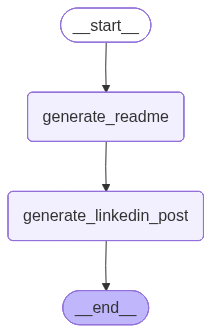

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
file_path = "./main.ipynb"

notebook_content = load_notebook(file_path)

In [13]:
result = graph.invoke({
    "notebook_content": notebook_content
})

In [14]:
print(result["readme"])

# AI‑Powered README & LinkedIn Post Generator for Jupyter Notebooks  

## Overview  
This repository contains a **self‑contained Jupyter notebook** that automatically generates a professional GitHub README and a LinkedIn post from any Jupyter Notebook (`.ipynb`). By leveraging the Groq LLM (via LangChain) and a lightweight state‑graph workflow (LangGraph), the tool extracts the notebook’s markdown and code cells, feeds them to a prompt‑engineered LLM, and writes the resulting artifacts to disk.  

## Problem Statement  
Creating high‑quality documentation and social‑media summaries for data‑science or ML projects is time‑consuming and often inconsistent. Developers must manually:  

1. Read through the notebook to understand its purpose.  
2. Draft a structured README that covers project context, tech stack, usage, etc.  
3. Write a concise LinkedIn post to showcase the work.  

These steps are repetitive, error‑prone, and distract from core development work.  

## Approach  
1. **Load

In [15]:
print(result["linkedin_post"])

🚀 **Introducing an AI‑Powered README & LinkedIn Post Generator for Jupyter Notebooks** 🚀  

Data‑science and ML teams spend countless hours turning notebook insights into polished documentation and social‑media updates. My latest open‑source notebook automates that entire workflow:

1️⃣ **Parse any `.ipynb`** – using `nbformat` to pull together markdown and code cells.  
2️⃣ **Prompt‑engineer a Groq LLM (via LangChain)** – one template crafts a full‑featured GitHub README, the second uses that README to write a concise, technically‑savvy LinkedIn post.  
3️⃣ **Orchestrate with LangGraph** – a lightweight state‑graph runs `generate_readme` → `generate_linkedin_post`, guaranteeing deterministic execution.  
4️⃣ **Persist outputs** – `README_generated.md` and `linkedin_post.txt` are written to disk automatically, ready for commit or copy‑paste.  

**Tech stack**: Python 3.10+, `nbformat`, `python-dotenv`, `langchain-core`, `langchain-groq`, `langgraph`, IPython/Mermaid for visualisation, 

In [16]:
with open("README_generated.md", "w") as f:
    f.write(result["readme"])

with open("linkedin_post.txt", "w") as f:
    f.write(result["linkedin_post"])